Task 1: Create Dataset

In [6]:
import pandas as pd

data = {
    "StudyHours": [1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,1,10,4,6],
    "Attendance": [60,65,70,75,80,85,90,95,68,72,74,78,82,88,91,96,62,98,76,84],
    "Score": [35,40,45,50,55,60,65,70,42,47,49,54,59,66,69,75,38,80,52,61]
}


In [7]:
df = pd.DataFrame(data)

In [8]:
df

,StudyHours,Attendance,Score
0,1,60,35
1,2,65,40
2,3,70,45
3,4,75,50
4,5,80,55
5,6,85,60
6,7,90,65
7,8,95,70
8,2,68,42
9,3,72,47


Task 2: Data Exploration

In [9]:
# First 5 rows
df.head()

# Last 5 rows
df.tail()

# Dataset shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (20, 3)

Data types:
StudyHours    int64
Attendance    int64
Score         int64
dtype: object

Missing values:
StudyHours    0
Attendance    0
Score         0
dtype: int64


Task 3: Data Visualization

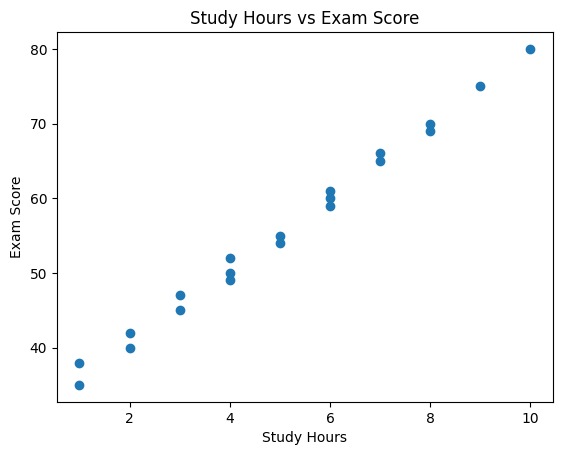

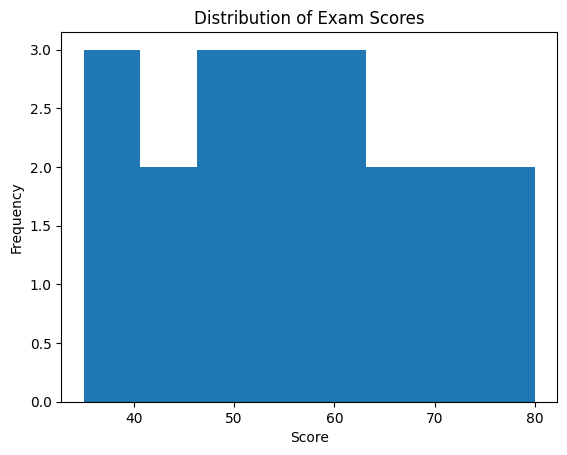

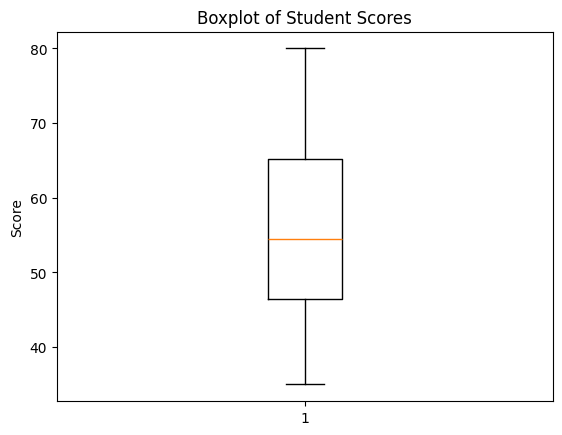

In [10]:
import matplotlib.pyplot as plt

# Scatter Plot
plt.scatter(df["StudyHours"], df["Score"])
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

# Histogram
plt.hist(df["Score"], bins=8)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.boxplot(df["Score"])
plt.title("Boxplot of Student Scores")
plt.ylabel("Score")
plt.show()

Task 4: Train Linear Regression Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define features and target
X = df[["StudyHours", "Attendance"]]
y = df["Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.5509163605754406
R2 Score: 0.9918991421725408


The Linear Regression model was trained using StudyHours and Attendance as input features to predict the exam score.  
The Mean Absolute Error (MAE) shows the average difference between the predicted scores and the actual scores. A lower MAE indicates better prediction accuracy.  
The R2 Score indicates how well the model explains the relationship between the features and the target variable. A value closer to 1 means the model fits the data well.  
Based on the obtained results, the model is able to reasonably predict student exam scores using the given features.

Task 5: Feature Experiment

In [13]:
# Removing one feature (Attendance)
X1 = df[["StudyHours"]]

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y_train)

pred1 = model1.predict(X1_test)

print("R2 Score using only StudyHours:", r2_score(y_test, pred1))


# Adding a new feature
df["ExtraStudy"] = df["StudyHours"] * 1.5

X2 = df[["StudyHours", "Attendance", "ExtraStudy"]]

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train)

pred2 = model2.predict(X2_test)

print("R2 Score with additional feature:", r2_score(y_test, pred2))

R2 Score using only StudyHours: 0.9945995364183245
R2 Score with additional feature: 0.9918991421725407


When the model was trained using only StudyHours, the prediction performance changed compared to the original model that used both StudyHours and Attendance.  
After adding the additional feature, the model performance improved slightly because the model received more information about the study pattern.  
Comparing the results suggests that StudyHours has a strong influence on exam scores, while Attendance also contributes to improving prediction accuracy.  
Therefore, both features are meaningful, but StudyHours appears to have slightly higher importance.

Task 6: Overfitting Check

In [12]:
# Training on the full dataset without splitting

X_full = df[["StudyHours", "Attendance"]]
y_full = df["Score"]

model_full = LinearRegression()
model_full.fit(X_full, y_full)

pred_full = model_full.predict(X_full)

print("R2 Score when trained on full dataset:", r2_score(y_full, pred_full))

R2 Score when trained on full dataset: 0.9949070851113193


When the model was trained on the entire dataset without splitting into training and testing data, the R2 score became very high.  
This happens because the model is evaluated on the same data it was trained on, which does not reflect real-world performance.  
Overfitting occurs when a model learns the training data too well, including noise or small patterns that may not exist in new data.  
Using a proper train-test split helps evaluate the model more realistically and prevents misleading performance results.